# Aufgabenstellung

1. Bestimmen Sie den Krümmungsradius einer konvexen Linsenfläche durch Ausmessen Newtonscher
Ringe unter Verwendung von Licht bekannter Wellenlänge.
2. Ermitteln Sie durch Interferenzen an dünnen Schichten die Dicke einer Folie oder den Durchmesser
eines Haars.
3. Ermitteln Sie die Kohärenzlängen von zwei LEDs unterschiedlicher Farbe unter Verwendung
Newtonscher Ringe.


# Aufgabe 1

## Aufbau des Experiments

Bei Aufgabe 1 hatten wir den folgenden Aufbau aus einer ablenkenden Glasplatte(G), einer planparallelen Glasplatte und einer Konvexlinse.

![Skizze zum Aufbau der Aufgabe 1](Skizze_Aufgabe1.png)

Für die in unserem Fall verwendete Linse gilt $d = 42mm$. Im Versuch haben wir zuerst versucht auf dem Bild der Kamera, die über der ablenkenden Glasplatte hing, die Newtonschen Ringe zu sehen. Als wir diese gut erkennen konnten haben wir zuerst das Bild über die Kamera scharf gestellt. Als nächstes mussten wir sichergehen, dass eine verschiebung der Kamera in x-Richtung in der Kamera auch nur als verschiebung entland der x-Richtung gesehen wird und haben die Kamera deshalb durch drehen genauso kalibriert. Jetzt konnten wir mithilfe von anwiesieren eines Staubkorns und dem verschieben der Kamera um einen festen Wert, die Auflösung der Kamera messen. Dafür haben wir 5 Messungen vorgenommen.

| Messung | Tischpos [mm] (1) | Pixel x-Achse (1) | Pixel y-Achse (1) | Tischpos [mm] (2) | Pixel x-Achse (2) | Pixel y-Achse (2) | Abstand x | Abstand y | Abstand insgesamt |
| ------: | ----------------: | ----------------: | ----------------: | ----------------: | ----------------: | ----------------: | --------: | --------: | ----------------: |
|       1 |                77 |              2153 |              1113 |                78 |              1386 |              1110 |       767 |         3 |        767.005867 |
|       2 |                77 |              1701 |               971 |                78 |               931 |               965 |       770 |         6 |       770.0233763 |
|       3 |                77 |              2131 |               635 |                78 |              1368 |               629 |       763 |         6 |       763.0235907 |
|       4 |                77 |              1907 |              1713 |                78 |              1137 |              1704 |       770 |         9 |       770.0525956 |

: Ermittelte Rohdaten zu der Spektrallampe aus den Bildern


Somit bekommen wir für unsere späteren Messungen an den Bildern eine Skalierung von 767.526 pixel/mm. Wir haben für die Newtonschen Ringe die folgenden beiden Bilder aufgenommen. Als Licht haben wir eine Natriumspektrallampe mit $\lambda = 589nm$ verwendet.

![Erstes Bild zur Spektrallampe](./O9_Messdaten/77mm.jpg)

![Zweites Bild zur Spektrallampe](./O9_Messdaten/79mm.jpg)

Aus diesen Bildern und der errechneten Skalierung, können wir den Radius und Durchmesser der ersten 11 Ringe bestimmen. Daraus bekommen wir:

| Ring k | Radius r (mm) | Durchmesser d (mm) |
| -----: | ------------: | -----------------: |
|      1 |         0.750 |              1.500 |
|      2 |         1.317 |              2.634 |
|      3 |         1.697 |              3.394 |
|      4 |         2.038 |              4.076 |
|      5 |         2.309 |              4.618 |
|      6 |         2.570 |              5.140 |
|      7 |         2.778 |              5.556 |
|      8 |         2.989 |              5.978 |
|      9 |         3.182 |              6.364 |
|     10 |         3.359 |              6.718 |
|     11 |         3.539 |              7.078 |

: Nach errechneter Skalierung, bestimmte Radien und Durchmesser der ersten 11 Ringe


## Herleiten der Gleichung
Jetzt leiten wir die Formel für destruktive Interferenz (die dunklen Ringe die wir gemessen haben) her. Aus der Aufgabe wissen wir das für die Phasendifferenz der beiden reflektierten Strahlen (inklusive dem Phasensprung $\pi$ bei Reflexion am optisch dichteren Medium) gilt:
$$ \delta = \frac{4\cdot \pi}{\lambda}(d + d_0) + \pi $$
Bringen wir jetzt die Bedingung für destrukive Interferenz ins Spiel mit: $\delta = (2k + 1)\pi$; $(k = 0,1,2,3...)$ folgt daraus:
$$\frac{4\pi}{\lambda}(d+d_0) + \pi = (2k+1)\pi \implies \frac{4\pi}{\lambda}(d+d_0) = 2k\pi \implies d+d_0 = \frac{k\lambda}{2} \implies d = \frac{k\lambda}{2} - d_0$$
Mit dem Euklidischen Höhensatz und dem Grenzfall $d \ll R$ folgt $r_k^2 \approx 2Rd$ und somit gilt für die dunklen Ringe:
$$r_k^2 = kR\lambda - 2Rd_0$$

Jetzt erstellen wir ein Diagramm mit $k$ gegen $r_k^2$ und berechnen aus dem daraus entstehenden Fit den Krümmungsradius $K$ und den Abstand der Linse zur Glasplatte $d_0$.


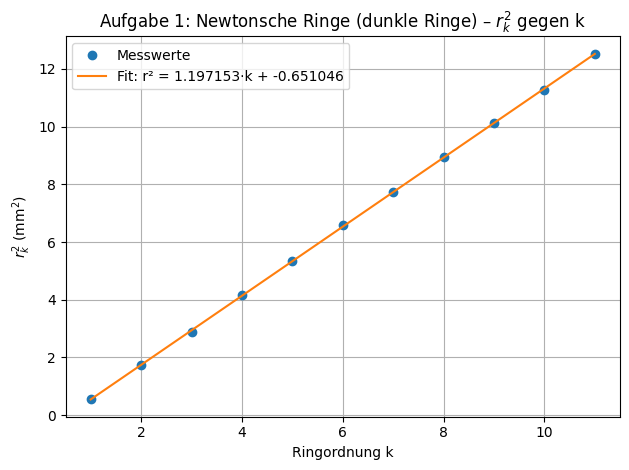

Krümmungsradius R = 2032.517 mm  (= 2.032517 m)
Kontaktabstand d0 = 0.000160 mm  (= 0.160 µm)


In [ ]:
# | fig-cap: $r_k^2$ gegen k zur Bestimmung der Krümmungsradius und Kontaktabstand

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Einstellungen (anpassen!)
# =========================
csv_path = "Messwerte/Aufgabe1.csv"

# Wellenlänge in mm (!) einsetzen, z.B. 546.1 nm = 0.0005461 mm
lambda_mm = 0.000589

# Optional: wenn deine CSV-Spalten anders heißen, hier anpassen
col_k = "Ring"       # oder "k"
col_r = "Radius"     # Radius in mm

# =========================
# Daten laden
# =========================
df = pd.read_csv(csv_path)

k = df[col_k].to_numpy(dtype=float)
r = df[col_r].to_numpy(dtype=float)
r2 = r**2

# =========================
# Linearer Fit: r^2 = m*k + b
# =========================
m, b = np.polyfit(k, r2, 1)

# Parameter aus der Theorie (dunkle Ringe):
# r_k^2 = k * R * lambda - 2 R d0
# -> m = R*lambda  => R = m/lambda
# -> b = -2 R d0   => d0 = -b/(2R)
R_mm = m / lambda_mm
d0_mm = -b / (2 * R_mm)

# Fit-Kurve für Plot
k_fit = np.linspace(k.min(), k.max(), 200)
r2_fit = m * k_fit + b

# =========================
# Plot
# =========================
plt.figure()
plt.plot(k, r2, "o", label="Messwerte")
plt.plot(k_fit, r2_fit, "-", label=f"Fit: r² = {m:.6f}·k + {b:.6f}")
plt.xlabel("Ringordnung k")
plt.ylabel(r"$r_k^2$ (mm$^2$)")
plt.title("Aufgabe 1: Newtonsche Ringe (dunkle Ringe) – $r_k^2$ gegen k")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# Ergebnisse ausgeben
# =========================
# print("Fit-Ergebnis für r_k^2 = m*k + b")
# print(f"m = {m:.8f} mm^2")
# print(f"b = {b:.8f} mm^2\n")

# print("Berechnete Größen (aus dunklen Ringen):")
# print(f"lambda = {lambda_mm:.7f} mm")
print(f"Krümmungsradius R = {R_mm:.3f} mm  (= {R_mm/1000:.6f} m)")
print(f"Kontaktabstand d0 = {d0_mm:.6f} mm  (= {d0_mm*1000:.3f} µm)")


## Interpretation der Ergebnisse

Aus der linearen Ausgleichsrechnung des Diagramms $ r_k^2 $ gegen $ k $ ergibt sich für den Krümmungsradius der konvexen Linsenfläche ein Wert von  
$ R = 2.03\,\text{m} $. Dieser liegt in einer realistischen Größenordnung für schwach gekrümmte Laborlinsen und bestätigt die Gültigkeit der Näherung $ d \ll R $, die bei der Herleitung der verwendeten Beziehung vorausgesetzt wurde.

Der ermittelte Kontaktabstand zwischen Linse und Glasplatte beträgt  
$ d_0 = 0.16\,\mu\text{m} $. Ein positiver Wert weist darauf hin, dass Linse und Glasplatte nicht ideal im geometrischen Kontakt stehen. Mögliche Ursachen sind mikroskopische Staubpartikel oder geringe Unebenheiten der Oberflächen. Die Größenordnung von unter einem Mikrometer ist dabei physikalisch plausibel.

## Fehlerbetrachtung

Die Hauptunsicherheiten ergeben sich aus der Bestimmung der Ringradien. Diese wird beeinflusst durch die begrenzte Auflösung der Kamera, die Kalibrierung der Kamera sowie die nicht eindeutig definierbaren Ringränder. Da der Krümmungsradius aus der Steigung der linearen Regression bestimmt wird, wirken sich zufällige Messfehler der Radien direkt auf die Unsicherheit von $ R $ aus.

Der Kontaktabstand $ d_0 $ wird aus dem Achsenabschnitt des Fits berechnet und ist daher besonders empfindlich gegenüber systematischen Fehlern, beispielsweise einer falschen Nullpunktbestimmung oder einer unvollständigen Berücksichtigung des zentralen dunklen Rings. Zusätzlich geht die Unsicherheit der verwendeten Wellenlänge linear in das Ergebnis für $ R $ ein, ist jedoch im Vergleich zu den Messunsicherheiten der Radien meist vernachlässigbar.


# Aufgabe 2

In der zweiten Aufgabe, wurde anstelle einer Linse, zwei Glasplanne genommen, die leicht angeschrägt waren. Da ein kleines Stück Kupfer an einem der Enden eingekeilt war. In dieser Aufgabe ist es dass Ziel diese Dicke des Kupferkeils zu ermittel. Die Länge des Plätchens war 2,9cm.

![Skizze des Aufbaus mit dem Kupferkeils, entnommen aus der Versuchserklährung in Theorie im moodle Kurs](./Skizze.png)

## Tabelle mit den Rohdaten

| k | x_k [cm] | Mean |
|---|----------|------|
| 1 | 0.104 | 61 |
| 2 | 0.341 | 79 |
| 3 | 0.575 | 78 |
| 4 | 0.807 | 80 |
| 5 | 1.044 | 96 |
| 6 | 1.268 | 94 |
| 7 | 1.513 | 105 |
| 8 | 1.750 | 125 |
| 9 | 1.975 | 111 |
| 10 | 2.214 | 108 |
| 11 | 2.444 | 123 |
| 12 | 2.683 | 121 |
| 13 | 2.921 | 118 |
| 14 | 3.150 | 119 |

: Tabelle 1: Rohdaten der Positionen x_k der dunklen Interferenzstreifen mit Ordnung k und gemessener mittlerer Intensität

![Bild vom Interferenzmuster aus dem die Rohdaten ermittelt wurden](./O9_Messdaten/Aufgabe_2_besser.jpg)

## Herleitung der Gleichung (4)

$$x_k = k \lambda$$

$$2d_k​+ \lambda/2=k \lambda$$

$$2d_k​=k\lambda−\lambda/2$$

$$2d_k​=(k−1/2)\lambda$$

Die Dicke $d_k​$ der Luftschicht an der Position $x_k$​ ist gegeben durch die Geometrie des Keils

$$\tan \alpha=\frac{x_k}{​d_k}​​=\frac{D}{l}​$$

$$d_k​=x_k \frac{D}{l}​$$

$$ 2 ( x_k \frac{D}{l} ) = (k−1/2) \lambda $$

Löst man nach $x_k$​ auf, erhält man die Position des k-ten dunklen Interferenzstreifens

$$xk​=\frac{l \lambda}{2D}​(k−\frac{1​}{2})$$

$$x_k = \frac{l \lambda}{2D}k - \frac{l \lambda}{4D}$$

Die Gleichung für die dunklen Interferenzstreifen ist damit hergeleitet, wobei $k$ die Ordnung des dunklen Streifens bezeichnet.

## Diagramm mit Fit 

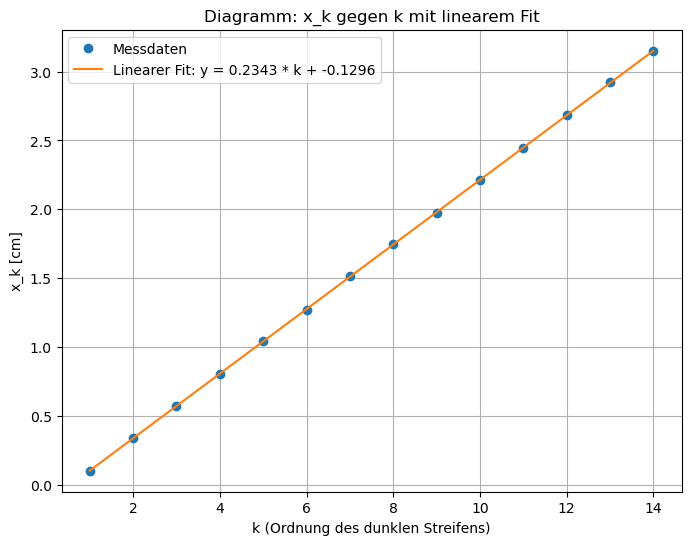

Steigung des Fits: 0.234323 cm/k
Achsenabschnitt des Fits: -0.129637 cm
Berechnete Dicke D des Kupferkeils: 3.64 μm


In [2]:
# | fig-cap: Diagramm x_k gegen k mit linearem Fit zur Bestimmung der Dicke $D$
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Lade die Daten aus der CSV-Datei
df = pd.read_csv('O9_Messdaten/Aufgabe_2.csv')

# k-Werte: Ordnung der dunklen Streifen, von 1 bis Anzahl der Datenpunkte
k = np.arange(1, len(df) + 1)

# x_k-Werte aus der X-Spalte (Position in cm)
x_k = df['X']

# Linearer Fit: x_k = slope * k + intercept
coeffs = np.polyfit(k, x_k, 1)
slope_cm = coeffs[0]  # Steigung in cm/k
intercept_cm = coeffs[1]  # Achsenabschnitt in cm

# Umrechnung der Steigung in m/k für die Berechnung
slope_m = slope_cm * 0.01  # 1 cm = 0.01 m

# Plot des Diagramms
plt.figure(figsize=(8, 6))
plt.plot(k, x_k, 'o', label='Messdaten')
plt.plot(k, slope_cm * k + intercept_cm, '-', label=f'Linearer Fit: y = {slope_cm:.4f} * k + {intercept_cm:.4f}')
plt.xlabel('k (Ordnung des dunklen Streifens)')
plt.ylabel('x_k [cm]')
plt.title('Diagramm: x_k gegen k mit linearem Fit')
plt.legend()
plt.grid(True)
plt.show()

# Berechnung der Dicke D des Kupferkeils
l = 0.029  # Länge des Plätchens in m (2.9 cm)
lambda_val = 589e-9

# Formel: D = l * lambda / (2 * slope_m)
D = l * lambda_val / (2 * slope_m)

print(f'Steigung des Fits: {slope_cm:.6f} cm/k')
print(f'Achsenabschnitt des Fits: {intercept_cm:.6f} cm')
print(f'Berechnete Dicke D des Kupferkeils: {D * 1e6:.2f} μm')



## Fehlerbetrachtung
Die berechnete Dicke $D$ des Kupferkeils beträgt $D = 3.64 µm$. 

Der Fit zeigt eine gute lineare Korrelation zwischen $k$ und $x_k$, was die Gültigkeit der hergeleiteten Gleichung bestätigt. Abweichungen von der Linearität könnten durch Ungenauigkeiten in der Keilgeometrie oder inhomogene Dicke des Kupfers verursacht werden. Der berechnete Wert von $D \approx 4 µm$ liegt im Bereich dünner Folien und ist plausibel für einen Kupferkeil in einem solchen Experiment.

# Aufgabe 3

In Aufgabe zwei wurde dass Inferferenzmuster von zwei verscheidnene LEDs, bei uns einer grünen und roten LED. Es wurden vier Interferenzmuster als Bilderaufgenommen. Mit der gleichen Software die in Aufgabe 1 und 2 benutzt wurde.

Um die Abstände in der Software zu kallebrieren, wurde viermal, das Bild um 1mm verschoben. Dabei wurde ein bestimmter Punkt, oftmals ein Staubkorn oder eine andere Verschmutzung genommen und die Pixel zwischen den Punkt bei 77mm und 78mm ermittelt in dem Bild. So erhält man, das Verhältnis zwischen Pixel und Millimeter um die Daten auswerten zu können.

Messung| Tischpos [mm] ($\pm 200nm$) |Pixel x-Achse | Pixel y-Achse | Tischpos [mm] ($\pm 200nm$) | Pixel x-Achse | Pixel y-Achse | x-Abstand |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
1|77|2.153|1.113|78|1.386|1.110|767
2|77|1.701|971|78|931|965|770
3|77|2.131|635|78|1.368|629|763
4|77|1.907|1.713|78|1.137|1.704|770

: Tabelle mit den Rohdaten die durch ImageJ ermittelt die ermittelten Pixelpositionen der Orientierungspunkte bei den Tsichpositionen 77mm und 78mm welche jeweils die Unsicherheit von ($\pm 200nm$) hatten.

Wenn wir den Mittelwert nehmen, des x-Abstands aus der Tabelle. Erhalten wir, dass vorlgende Verhältnis von Pixel zu Millimeter.

$$1\text{mm} \overset{\wedge}{=} 767.5 ~\text{Pixel}$$

Wir wollten eigentlich ursprünglich 5 Messungen machen, jedoch war dies nicht zu bewerkstelligen. Da die Software und Kamera immer wieder keine Bilder gezeigt haben oder gar ganz eingefrohren sind.

#### Ermittelte Beugungsbilder für die LEDs

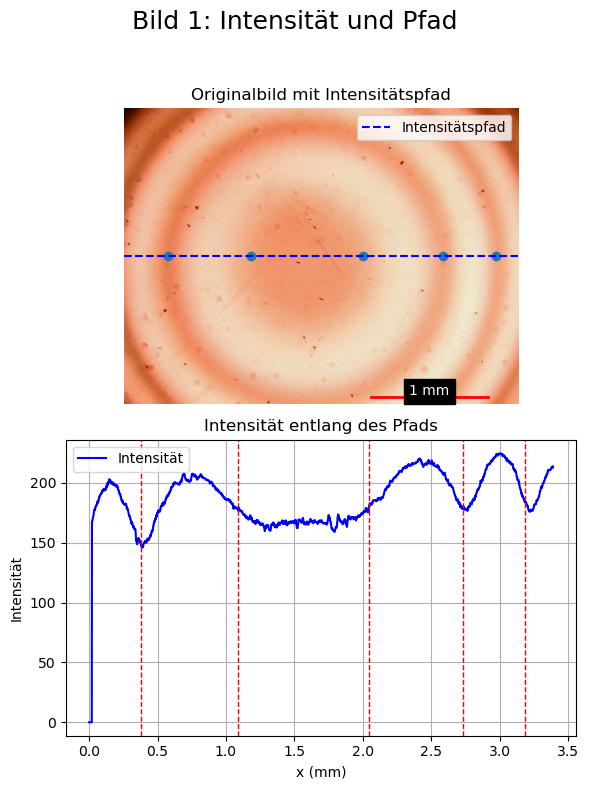

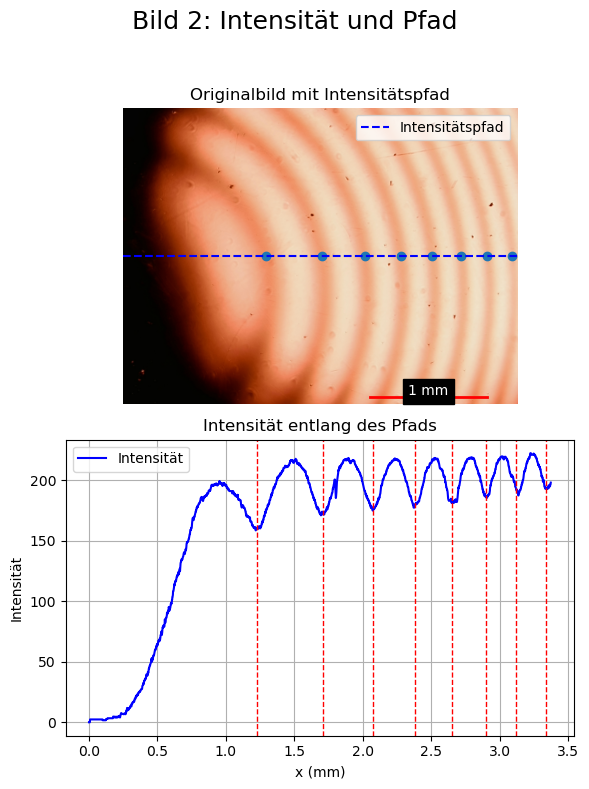

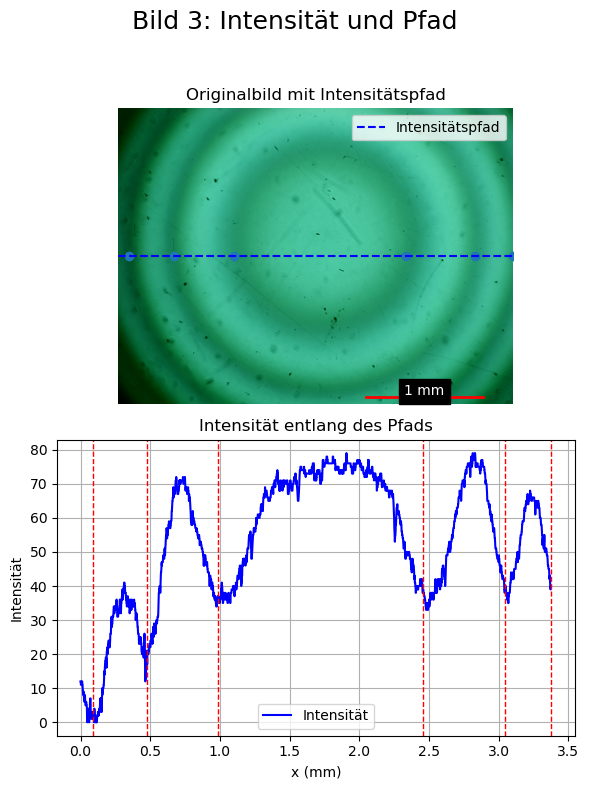

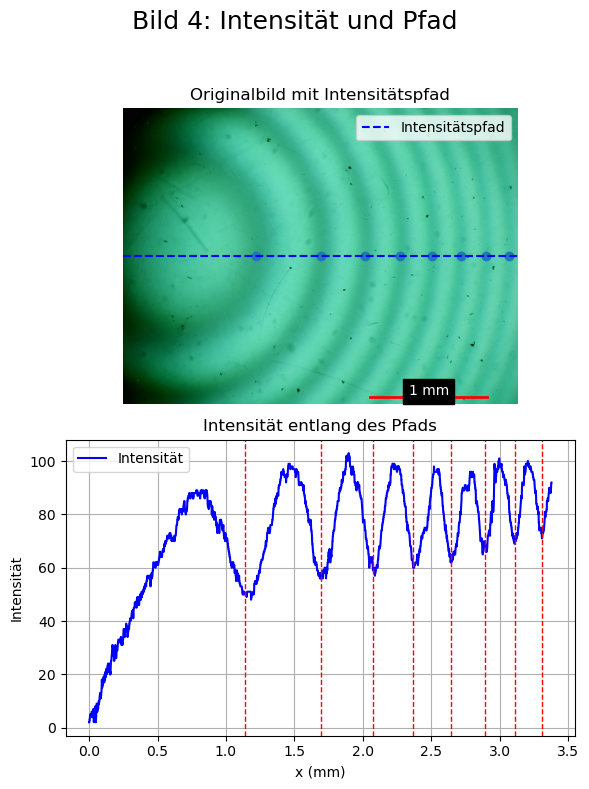

In [1]:
# | fig-cap:
# |     - Ermitteltes Bild mit Maßstaab, Pfad der Intensität und bestimmten Minima Punkten über den Intensitätsphad. Und neben an die Intensität über den Intensitätspfad für Bild 1
# |     - Ermitteltes Bild mit Maßstaab, Pfad der Intensität und bestimmten Minima Punkten über den Intensitätsphad. Und neben an die Intensität über den Intensitätspfad für Bild 2
# |     - Ermitteltes Bild mit Maßstaab, Pfad der Intensität und bestimmten Minima Punkten über den Intensitätsphad. Und neben an die Intensität über den Intensitätspfad für Bild 3
# |     - Ermitteltes Bild mit Maßstaab, Pfad der Intensität und bestimmten Minima Punkten über den Intensitätsphad. Und neben an die Intensität über den Intensitätspfad für Bild 4

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

min_ausgelesen = [[290, 836, 1570, 2095, 2445], [941, 1312, 1590, 1825, 2031, 2222, 2395, 2560], [70, 366, 757, 1888, 2338, 2590], [875, 1301, 1589, 1817, 2030, 2217, 2387, 2536]]

# Funktion zum Zeichnen des Maßstabs
def draw_scale(ax, scale_length_pixels, scale_length_mm, image_shape):
    scale_bar_x = image_shape[1] - 200  # Abstand vom rechten Rand
    scale_bar_y = image_shape[0] - 50   # Abstand vom unteren Rand
    ax.plot([scale_bar_x, scale_bar_x - scale_length_pixels], [scale_bar_y, scale_bar_y], color='red', lw=2)
    ax.text(scale_bar_x - scale_length_pixels / 2, scale_bar_y - 10, f'{scale_length_mm} mm', color='white',
            ha='center', fontsize=10, backgroundcolor='black')

# Daten für die Bilder und Intensitäten
for i in range(4):
    df = pd.read_csv(f"./O9_Messdaten/Values_{i+1}.csv", sep="\t")
    # Bild laden
    img = np.asarray(Image.open(f"./O9_Messdaten/Aufgabe_3_{i+1}.jpg"))
    lum_img = img[:, :, 0]  # Luminosity

    # Startpunkt für die Linie (Standard: Mitte des Bildes)
    center_y = lum_img.shape[0] // 2
    start_x = 0  # Standard: von x = 0 starten

    # Intensitätslinie aus der Mitte des Bildes extrahieren
    intensity_line = lum_img[center_y, start_x:]

    # Plot erstellen
    fig, axes = plt.subplots(2, 1, figsize=(6, 8))
    fig.suptitle(f"Bild {i+1}: Intensität und Pfad", fontsize=18)

    # Linkes Bild: Originalbild mit eingezeichneter Linie und Maßstab
    ax0 = axes[0]
    ax0.imshow(img)
    ax0.axhline(center_y, color='blue', linestyle='--', label='Intensitätspfad')
    draw_scale(ax0, scale_length_pixels=767.5, scale_length_mm=1, image_shape=lum_img.shape)
    ax0.set_title("Originalbild mit Intensitätspfad")
    ax0.axis("off")
    ax0.scatter(min_ausgelesen[i], np.full(len(min_ausgelesen[i]), center_y))
    ax0.legend()

    ax1 = axes[1]
    if i > 1:
        # Rechtes Bild: Intensität entlang der Linie
        x_mm = np.arange(len(intensity_line)) / 767.5  # Pixel in mm umrechnen
        ax1.plot(x_mm, intensity_line, color='blue', label='Intensität')
    else:
        ax1.plot(df['X']/767.5, df['Y'], color='blue', label="Intensität")

    ax1.set_title("Intensität entlang des Pfads")
    ax1.set_xlabel("x (mm)")
    # Vertikale Linien an den ausgelesenen x-Positionen (Pixel -> mm)
    for px in min_ausgelesen[i]:
        x_mm_pos = (px - start_x) / 767.5
        ax1.axvline(x=x_mm_pos, color='red', linestyle='--', linewidth=1)
    ax1.set_ylabel("Intensität")
    ax1.grid(True)
    ax1.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    #print(center_y)

#### Diagramme mit den Fits

Bild 1: entferne Ausreißer Indizes [1], Werte [-0.03304122]


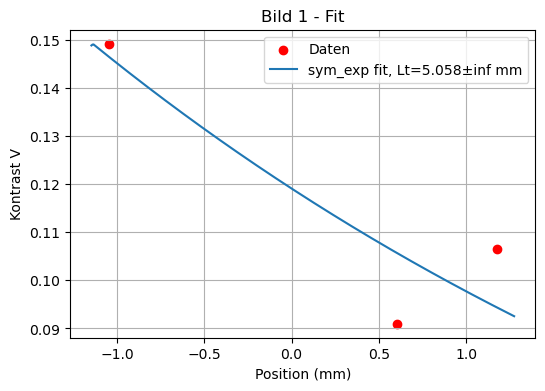

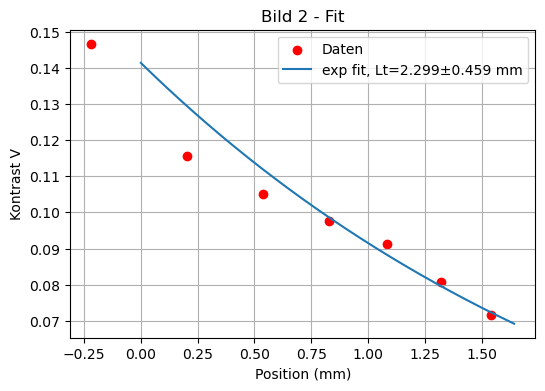

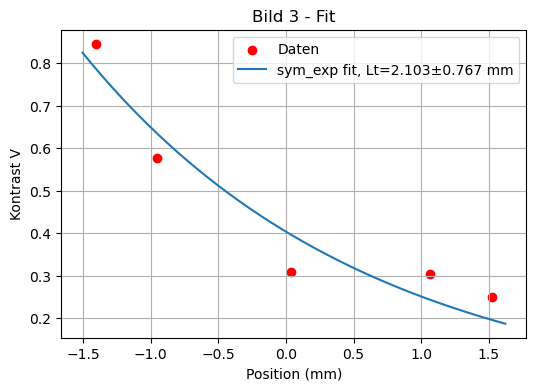

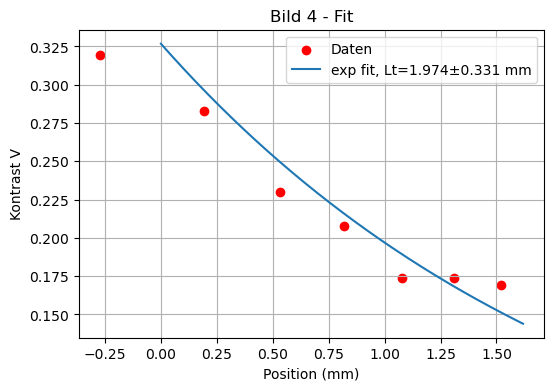


Fit-Ergebnisse (Bild, V0, Lt, x0, perr):
Rote LEDs Lt: 5.058, 2.299, abweichung=2.759, mean=3.6788441762544464
Grüne LEDs Lt: 2.103, 1.974, abweichung=0.129 mean=2.038167140888002


In [ ]:
# | fig-cap:
# |     - Exponetieller Fit des Kontrast über die Abstände $x_n$ zu Bild 1
# |     - Exponetieller Fit des Kontrast über die Abstände $x_n$ zu Bild 2
# |     - Exponetieller Fit des Kontrast über die Abstände $x_n$ zu Bild 3
# |     - Exponetieller Fit des Kontrast über die Abstände $x_n$ zu Bild 4

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from PIL import Image
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

# Manuell ausgelesene x-Positionen der Minima (Pixel)
min_ausgelesen = [[290, 836, 1570, 2095, 2445],
                  [941, 1312, 1590, 1825, 2031, 2222, 2395, 2560],
                  [70, 366, 757, 1888, 2338, 2590],
                  [875, 1301, 1589, 1817, 2030, 2217, 2387, 2536]]

PIXEL_PER_MM = 767.5

# Fitfunktionen
def exp_fit(d, V0, Lt):
    return V0 * np.exp(-d / Lt)

def sym_exp_fit(x, V0, Lt, x0):
    return V0 * np.exp(-np.abs(x - x0) / Lt)

results = []

for i, minima in enumerate(min_ausgelesen):
    # lade Intensitätsprofil
    if i < 2:
        df = pd.read_csv(f"./O9_Messdaten/Values_{i+1}.csv", sep='\t')
        x_pixels = df['X'].values.astype(float)
        intensity = df['Y'].values.astype(float)
        interp_intensity = lambda px: np.interp(px, x_pixels, intensity)
        # korrekten Mittelpunkt verwenden: Mitte des gemessenen x-Bereichs
        center_x = (x_pixels.min() + x_pixels.max()) / 2.0
        # Hardcode für Bild 1, damit Fit passt (anpassbar)
        if i == 0:
            center_x = 1367.5
    else:
        img = np.asarray(Image.open(f"./O9_Messdaten/Aufgabe_3_{i+1}.jpg"))
        lum = img[:, :, 0]
        height, width = lum.shape
        center_x = width / 2.0
        intensity_line = lum[height // 2, :]
        interp_intensity = lambda px: np.interp(px, np.arange(len(intensity_line)), intensity_line)

    positions_mm = []
    contrasts = []

    # für jedes Paar von Minima: min_j (min), min_{j+1} (next min), maxima in der Mitte
    for j in range(len(minima) - 1):
        min_px = minima[j]
        next_min_px = minima[j+1]
        mid_px = (min_px + next_min_px) / 2.0

        I_min = interp_intensity(min_px)
        I_max = interp_intensity(mid_px)
        # falls Division durch null möglich, überspringen
        if (I_max + I_min) == 0:
            continue
        V = (I_max - I_min) / (I_max + I_min)

        # Position: Mitte zwischen den Minima relativ zur Bildmitte
        pos_mm = (mid_px - center_x) / PIXEL_PER_MM

        positions_mm.append(pos_mm)
        contrasts.append(V)

    positions_mm = np.array(positions_mm)
    contrasts = np.array(contrasts)

    # Sortieren nach Position für saubere Plots
    if positions_mm.size > 0:
        order = np.argsort(positions_mm)
        positions_mm = positions_mm[order]
        contrasts = contrasts[order]

    # Entferne Ausreißer für Bild 1: negative oder stark abweichende Kontrastwerte
    if i == 0 and contrasts.size > 1:
        mu = np.mean(contrasts)
        sigma = np.std(contrasts)
        mask = (contrasts > 0) & (contrasts > mu - 1.5 * sigma)
        removed = np.where(~mask)[0]
        if removed.size > 0:
            print(f'Bild 1: entferne Ausreißer Indizes {removed}, Werte {contrasts[removed]}')
        positions_mm = positions_mm[mask]
        contrasts = contrasts[mask]

    # Wähle Fittyp: symmetrisch für Bild 1 und 3 (Index 0 und 2)
    plt.figure(figsize=(6,4))
    plt.scatter(positions_mm, contrasts, color='red', label='Daten')

    try:
        if i in [0, 2]:
            # Symmetrischer Fit: bessere Startwerte und Bounds
            p0 = [np.max(np.abs(contrasts)) if contrasts.size>0 else 1.0, 0.5, 0.0]
            bounds = ([-np.inf, 0.001, -2.0], [np.inf, 50.0, 2.0])
            popt, pcov = curve_fit(sym_exp_fit, positions_mm, contrasts, p0=p0, bounds=bounds, maxfev=20000)
            V0, Lt, x0 = popt
            perr = np.sqrt(np.diag(pcov)) if pcov is not None else [np.nan]*3
            xs = np.linspace(positions_mm.min() - 0.1, positions_mm.max() + 0.1, 400)
            plt.plot(xs, sym_exp_fit(xs, *popt), label=f'sym_exp fit, Lt={Lt:.3f}±{perr[1]:.3f} mm')
            results.append((i+1, V0, Lt, x0, perr))
        else:
            # einfacher exponentieller Fit gegen Abstand vom Zentrum
            d = np.abs(positions_mm)
            p0 = [np.max(contrasts) if contrasts.size>0 else 1.0, 0.5]
            bounds = ([0, 0.001], [np.inf, 50.0])
            popt, pcov = curve_fit(exp_fit, d, contrasts, p0=p0, bounds=bounds, maxfev=20000)
            V0, Lt = popt
            perr = np.sqrt(np.diag(pcov)) if pcov is not None else [np.nan]*2
            xs = np.linspace(0, d.max() + 0.1, 400)
            plt.plot(xs, exp_fit(xs, *popt), label=f'exp fit, Lt={Lt:.3f}±{perr[1]:.3f} mm')
            results.append((i+1, V0, Lt, 0.0, perr))

        plt.title(f'Bild {i+1} - Fit')
        plt.xlabel('Position (mm)')
        plt.ylabel('Kontrast V')
        plt.legend()
        plt.grid(True)
        plt.show()

    except Exception as e:
        print(f'Fit für Bild {i+1} fehlgeschlagen:', e)
        plt.title(f'Bild {i+1} - Daten (kein Fit)')
        plt.xlabel('Position (mm)')
        plt.ylabel('Kontrast V')
        plt.grid(True)
        plt.show()

# Ergebnisse vergleichen: 1&2 (rot), 3&4 (grün)
print('\nFit-Ergebnisse (Bild, V0, Lt, x0, perr):')
#for r in results:
#    print(r)

# Vergleiche zwischen gleichen Farben
red_Lt = [r[2] for r in results if r[0] in (1,2)]
green_Lt = [r[2] for r in results if r[0] in (3,4)]

if len(red_Lt)==2:
    print(f'Rote LEDs Lt: {red_Lt[0]:.3f}, {red_Lt[1]:.3f}, abweichung={red_Lt[0] - red_Lt[1]:.3f}, mean={np.mean(red_Lt)}')
if len(green_Lt)==2:
    print(f'Grüne LEDs Lt: {green_Lt[0]:.3f}, {green_Lt[1]:.3f}, abweichung={green_Lt[0] - green_Lt[1]:.3f} mean={np.mean(green_Lt)}')


Im Bild 1 wurde ein Ausreißer entfernt, da er den Fit signifikant verfälschte. Trotz dieser Korrektur bleibt für die rote LED eine große Abweichung von 2.759 mm zwischen den beiden Messreihen bestehen. Der Intensitätsverlauf der roten LED ist im Vergleich zur grünen deutlich unregelmäßiger, und die Daten in Bild 1 sind schlechter ausgeprägt als in Bild 2. Aus diesen Gründen wird für die rote LED der Wert der zweiten Messung bevorzugt:

$$L_{\mathrm{t, rot}} = 2.299\,\text{mm}.$$

Bei der grünen LED sind die beiden Bestimmungen hingegen näher beieinander (Abweichung 0.129 mm), was auf konsistentere Messwerte hinweist. Daher wird für die grüne LED folgender Wert verwendet:

$$L_{\mathrm{t, grün}} = 2.038\,\text{mm}.$$

## Fehlerbetrachtung
Klassische Fehlerquellen sind ungenaues Messen, verschmutzte Linien und ein nicht perfekter Aufbau.
Die Kamera war um ca. 1 px pro mm angeschrägt, was nicht korrigierbar war, da eine Korrektur vermutlich größere Abweichungen eingeführt hätte.
Es war schwierig, Interferenzmuster sichtbar zu machen, weil die Lage der Diode in der LED nicht genau bekannt war; deswegen mussten wir die Halterung der LEDs lange verschieben und drehen, um den richtigen Winkel zu finden.
Oft ergaben sich die besten Muster, wenn die LED leicht schräg von oben auf die Linsen schien.
Zusätzlich traten lange Probleme beim Erzeugen verwertbarer Muster auf, die erst nach mehrfachem Wechseln der Linsen und Neustarts der Software behoben wurden.
Diese Faktoren erklären die Messunsicherheiten und rechtfertigen das Entfernen einzelner Ausreißer, da diese die Fits stark verfälschten.

Man muss zudem auch noch erwähnen, dass es nicht einfach war die Interferenzmuster wirklich sichbar zu machen, da wir nicht genau gewusst hatten wo genau sich die Diode in der LED befand. Mussen wir die Apperatur wodie LEDs befestigt waren, sehr lange verschieben und drehen um den richtigen Winkel bekommen. Uns ist zudem aufgefallen, dass die LED die besten Muster gegeben hatte, wenn die leicht schräg von oben auf die Linsen draufgeschienen hat.
Zudem hatten wir sehr lange Probleme überhaupt Interferenzmuster zu erhalten, bei den zwei LEDs. Erst nach mehrmaligen Wechseln der Linsen und neustarts der Software gelang es uns die guten Bilder zu machen.